In [4]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import torch
import keras
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from umap import UMAP
import xarray as xr
from scipy.signal import sosfiltfilt, butter, welch
from meegkit import dss
from src.EEGModalNet.models.FiLMGAN import FiLMGAN
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data


# helpers
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

# REAL DATA
def open_real_data(eeg_data_path, channels, n_subjects=202, time_dim=512, condition='EC'):
    xarray = xr.open_dataarray(eeg_data_path, engine='h5netcdf')

    x = xarray.sel(subject=xarray.subject[:n_subjects], channel=channels)
    x = x.to_numpy()

    # preprocess
    x = preprocess_data(x, sampling_rate=128)

    # filter
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

    # line noise removal
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

    raw_real = x.copy()
    x = segment_data(x, time_dim)
    sub = torch.tensor(np.arange(0, n_subjects).repeat(x.shape[0]//n_subjects)[:, np.newaxis])

    fill_v = 0 if condition == 'EC' else 1
    state = torch.full_like(sub, fill_value=fill_v) 
    return x, sub, state, raw_real

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)
      
def generate_data(
    model,
    x,
    sub,
    pos,
    n_subjects,
    latent_dim=128,
    use_random_sub=False,
    device=None,
):
    """
    x:      (B, T, C) real data (only used for shape / optional stats later)
    sub:    (B, 1) subject ids for each segment
    pos:    (B, T, D_pos) positional encodings
    """

    model.generator.eval()

    if device is None:
        # infer device from model
        device = next(model.generator.parameters()).device
    else:
        device = torch.device(device)

    x      = x.float().to(device)
    sub    = sub.to(device)
    pos    = pos.to(device)

    B, T, C = x.shape
    x_gen   = torch.zeros_like(x)

    # assume balanced per-subject chunks
    bs = B // n_subjects
    n_chunks = B // bs

    for i in range(n_chunks):
        start = i * bs
        end   = (i + 1) * bs

        if use_random_sub:
            # sample labels uniformly in [0, n_subjects)
            sub_batch = torch.randint(0, n_subjects, (bs, 1), device=device)
        else:
            sub_batch = sub[start:end]

        z = torch.randn(bs, latent_dim, device=device)
        pos_batch = pos[start:end]

        with torch.no_grad():
            x_gen_batch = model.generator((z, sub_batch, pos_batch))
        x_gen[start:end] = x_gen_batch.cpu()

    # handle residual if B not divisible by bs
    tr_sh = (B // bs) * bs
    if tr_sh < B:
        res = B - tr_sh
        print("creating the residuals")

        if use_random_sub:
            sub_batch = torch.randint(0, n_subjects, (res, 1), device=device)
        else:
            sub_batch = sub[-res:]

        z = torch.randn(res, latent_dim, device=device)
        pos_batch = pos[-res:]

        with torch.no_grad():
            x_gen_tail = model.generator((z, sub_batch, pos_batch))
        x_gen[-res:] = x_gen_tail.cpu()

    return x_gen


In [5]:
# Data Parameters
TIME_DIM = 512
N_SUBJECTS = 10
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']
LATENT_DIM = 128

# real data
x, sub, state, _ = open_real_data(
    eeg_data_path='data/LEMON_DATA/EC_ch-8_sf-128.nc5',
    channels=CHANNELS,
    n_subjects=N_SUBJECTS,
    time_dim=TIME_DIM,
    condition='EC'
)

# fake data

CHECKPOINTS_PATH = 'logs/eo/20260302_v2_best_gloss.model.keras'

model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)

with torch.no_grad():
     x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

>>>>Corrected Mean: 1.627588775771753e-05, Std: 5.7597093459951364e-05, Max: 0.0009309873669414916, Min: -0.0005640464784786495
>>>>Scaled Mean: -0.010236472364015108, Std: 0.956387622382961, Max: 8.937554591320529, Min: -9.63112881125049
>>>>Normalized Mean: 4.366877230192282e-17, Std: 1.0000000000000002, Max: 5.453717499869226, Min: -6.7389061825036025
>>>>Clamped Mean: 4.366877230192282e-17, Std: 1.0000000000000002, Max: 5.453717499869226, Min: -6.7389061825036025
Power of components removed by DSS: 0.01


In [ ]:
fake_real = torch.concat([x.flatten(1), x_gen.flatten(1)], dim=0)

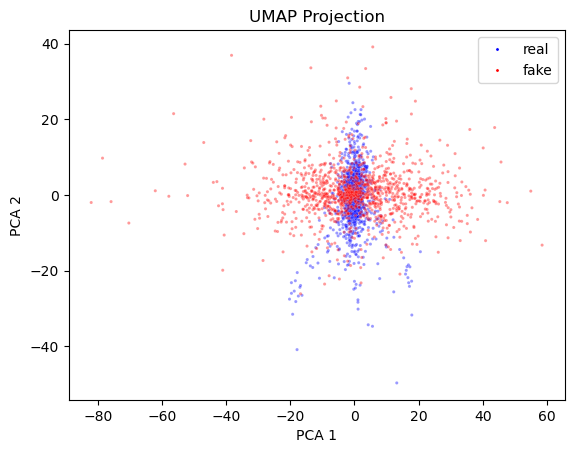

In [12]:
# PCA

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
)

x_pca = pipe.fit_transform(fake_real.numpy())

g = sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=['real'] * len(x) + ['fake'] * len(x_gen),
    palette=['blue', 'red'],
    alpha=0.4,
    s=5,
)
g.set_title('UMAP Projection')
g.set_ylabel('PCA 2')
g.set_xlabel('PCA 1')
# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')

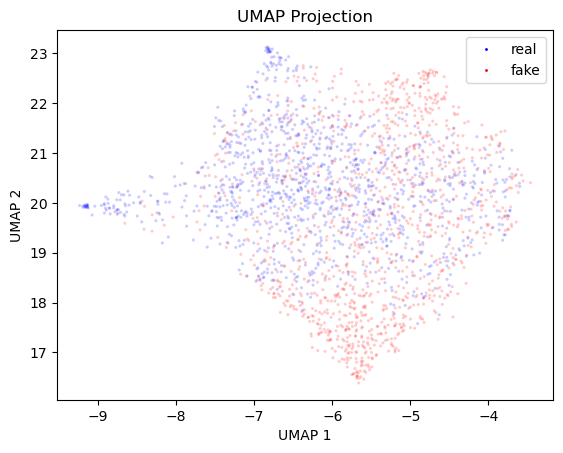

In [ ]:
# UMAP Viz
fake_real = torch.concat([x.flatten(1), x_gen.flatten(1)], dim=0)

# UMAP
umapper = UMAP()
x_umap = umapper.fit_transform(fake_real.numpy())

g = sns.scatterplot(
    x=x_umap[:, 0],
    y=x_umap[:, 1],
    hue=['real'] * len(x) + ['fake'] * len(x_gen),
    palette=['blue', 'red'],
    alpha=0.2,
    s=5,
)

g.set_title('UMAP Projection')
g.set_ylabel('UMAP 2')
g.set_xlabel('UMAP 1')

# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')